In [159]:
import importlib
import SOM
importlib.reload(SOM)
from SOM import SOM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Cargamos los datos

In [134]:
X = pd.read_csv('./data/te.csv')
X = X.values.astype(float)

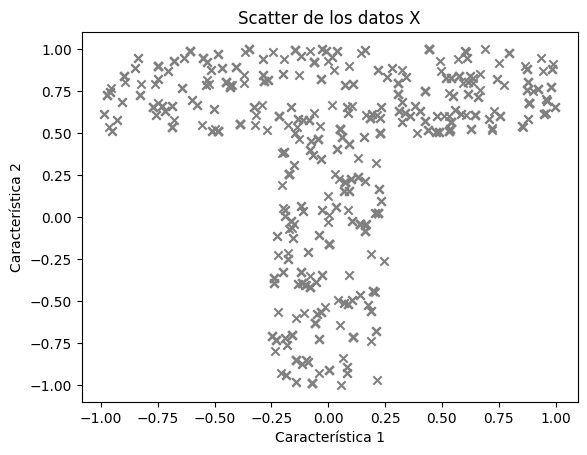

In [147]:
plt.scatter(X[:,0], X[:,1], marker='x', color='grey') 
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Scatter de los datos X')
plt.show()


## 1. Ordenamiento topologico
🎯 **Objetivo**: Organizar el mapa a gran escala

📝 **Descripcion**: Tiene como maximo 500-1000 epocas, una vel de aprendizaje cte de $0.9$ y un radio de vecinos alto (aprox. la mitad del mapa neuronal).

*Se pueden utilizar solo 30 epocas porque es un problema sencillo

In [171]:

map_size = 5
# Inicializamos los pesos
som = SOM(map_size)

som.fit(X, 30, [0.9, 0.9], [2, 2])



El entrenamiento finalizó en la época 29 en 0.96 segundos.


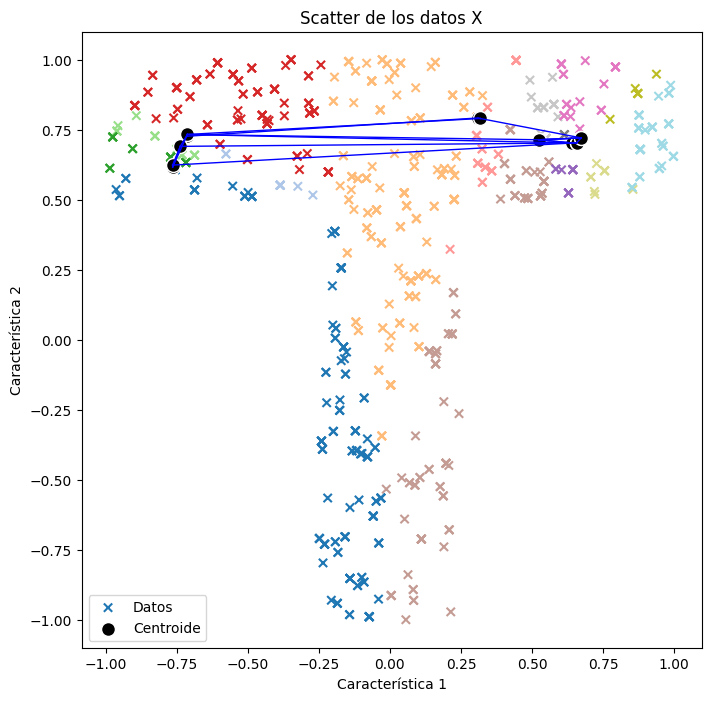

In [172]:
som.graficar(X)

## 2. Etapa de transicion
🎯 **Objetivo**: pasar de una organizacion global a una mas precisa

📝 **Descripcion**: Esta etapa tiene como maximo 1000 epocas, una vel. de aprendizaje que decrece de manera lineal y un rando de vecinos que tambien decrece hasta $r=1$

El entrenamiento finalizó en la época 49 en 1.49 segundos.


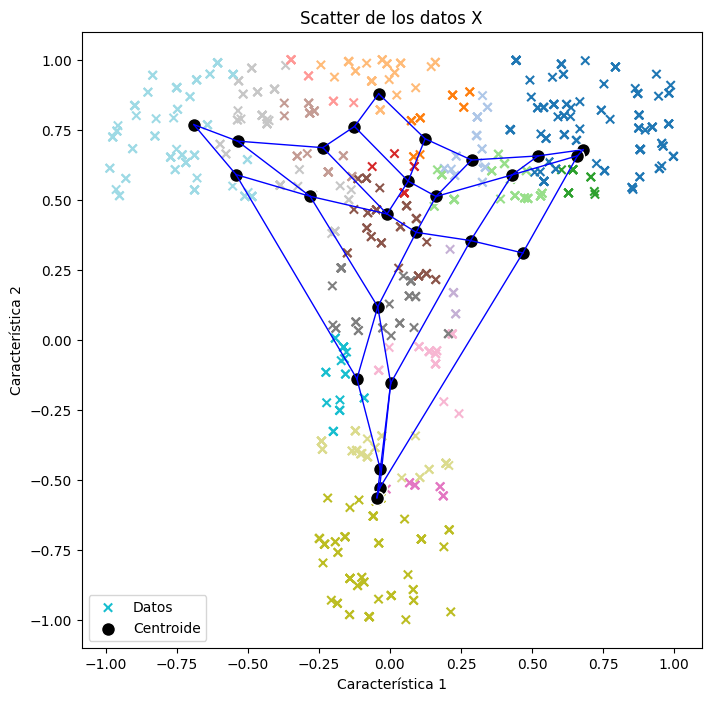

In [173]:
som.fit(X, 50, [0.9, 0.1], [3, 1])

som.graficar(X)


## 3. Ajuste fino
🎯 **Objetivo**: Realizar pequeños ajustes finales en los pesos

📝 **Descripcion**: Esta etapa tiene como maximo 3000 epocas, una vel. de aprendizaje cte entre $[0.1, 0.01]$ y un radio de vecinos igual a 0, es decir, solo actualizamos la neurona ganadora. 

El entrenamiento finalizó en la época 49 en 0.58 segundos.


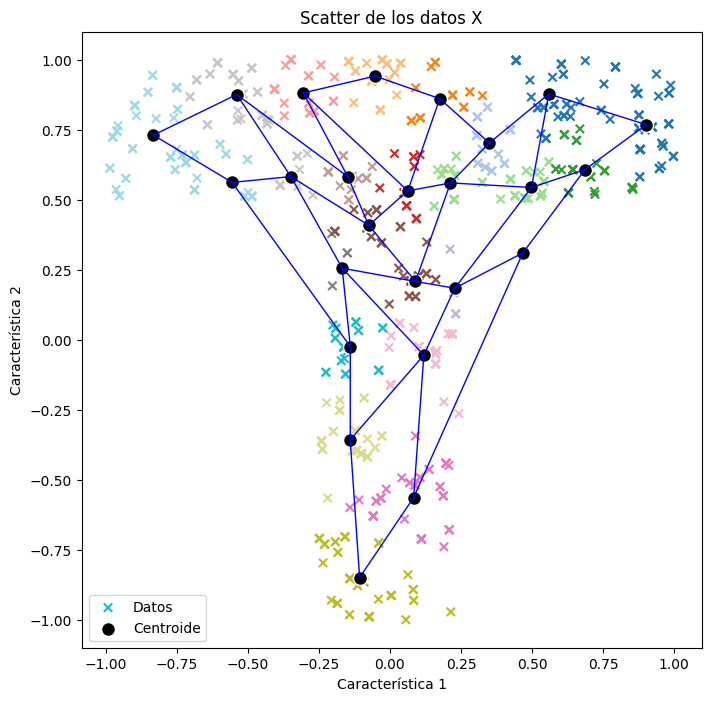

In [174]:
# Inicializamos los pesos
som.fit(X, 50, [0.01, 0.01], [0, 0])

som.graficar(X)